### Dataset Overview

The final dataset is a country-year panel consisting of 16 advanced economies from 2000–2023.

The dataset combines:
- unemployment outcomes,
- labour market coordination measures,
- and macroeconomic control variables.

The panel structure allows comparison of labour market resilience across countries and over time.

The sample consists of advanced economies with varying labour market coordination systems.

These include:
- Liberal market economies (e.g., United States, United Kingdom)
- Mixed coordination systems (e.g., Australia, Japan)
- Highly coordinated economies (e.g., Sweden, Germany, Denmark)

In [3]:
import pandas as pd
from pathlib import Path

# Load final merged panel dataset
panel = pd.read_csv(Path("data/clean/final_panel.csv"))

# Preview
display(panel.head())

# Shape
print(panel.shape)

,Country,Year,Unemployment,Delta_Unemployment,COORD,GDPGrowth,Inflation,ExportDependence,GovSpend
0,Australia,2000,6.288,NaN,2.0,3.916057,4.457437,19.356083,18.505430
1,Australia,2001,6.747,0.459,2.0,2.031459,4.407130,22.109757,18.507007
2,Australia,2002,6.375,-0.372,2.0,3.949805,2.981571,20.692768,18.318430
3,Australia,2003,5.933,-0.442,2.0,3.091280,2.732598,19.025563,18.380148
4,Australia,2004,5.399,-0.534,2.0,4.218941,2.343257,17.135063,18.273056


(384, 9)


The dataset contains 384 country-year observations across 16 advanced economies.

Most variables are numeric and suitable for panel-data econometric analysis.

There are no missing values within the datasets, besides the COORD, which has been imputed with its own data due to its time-invariant trait.

In [5]:
panel["Country"].unique()

<StringArray>
[     'Australia',        'Austria',        'Belgium',         'Canada',
        'Denmark',        'Finland',        'Germany',          'Japan',
    'Netherlands',    'New Zealand',         'Norway',    'South Korea',
         'Sweden',    'Switzerland', 'United Kingdom',  'United States']
Length: 16, dtype: str

### COORD Distribution

<Axes: xlabel='COORD'>

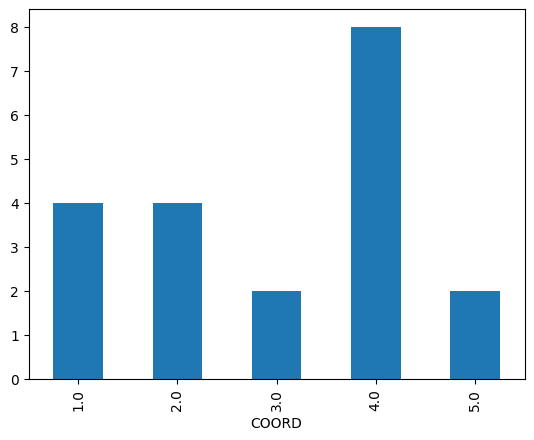

In [8]:
coord_counts = panel.groupby("COORD")["Country"].nunique()

coord_counts.plot(kind="bar")

### Tabulised Summary Statistics

In [7]:
import pandas as pd
from pathlib import Path

# Load final merged panel dataset
panel = pd.read_csv(Path("data/clean/final_panel.csv"))

# Preview
display(panel.head())

# Summary statistics
summary_stats = panel.describe().T

display(summary_stats)

# Dataset shape
print(panel.shape)

,Country,Year,Unemployment,Delta_Unemployment,COORD,GDPGrowth,Inflation,ExportDependence,GovSpend
0,Australia,2000,6.288,NaN,2.0,3.916057,4.457437,19.356083,18.505430
1,Australia,2001,6.747,0.459,2.0,2.031459,4.407130,22.109757,18.507007
2,Australia,2002,6.375,-0.372,2.0,3.949805,2.981571,20.692768,18.318430
3,Australia,2003,5.933,-0.442,2.0,3.091280,2.732598,19.025563,18.380148
4,Australia,2004,5.399,-0.534,2.0,4.218941,2.343257,17.135063,18.273056


,count,mean,std,min,25%,50%,75%,max
Year,384.0,2011.500000,6.931217,2000.000000,2005.750000,2011.500000,2017.250000,2023.000000
Unemployment,384.0,5.494643,1.857499,2.119000,4.041750,5.116500,6.838250,11.193000
Delta_Unemployment,368.0,-0.043674,0.772875,-2.706000,-0.459000,-0.119500,0.303250,4.386000
COORD,384.0,3.028646,1.311413,1.000000,2.000000,4.000000,4.000000,5.000000
GDPGrowth,384.0,1.905759,2.278520,-10.047897,1.038402,2.152377,3.103571,9.201858
Inflation,384.0,2.074884,1.717214,-1.352837,1.020175,1.909018,2.676063,10.001208
ExportDependence,384.0,41.579076,19.433554,9.035659,28.632096,40.104494,53.016865,96.443622
GovSpend,381.0,19.915420,4.023576,10.424410,18.123152,19.926177,23.097851,27.815694


(384, 9)




The sample includes substantial institutional variation across labour market coordination systems, ranging from decentralized bargaining systems to highly coordinated corporatist systems. This variation is important for identifying the relationship between labour market coordination and unemployment resilience.



The unemployment rate displays meaningful variation across countries and over time, particularly during major economic shocks such as the Global Financial Crisis and COVID-19.

COORD exhibits less variation over time, reflecting the relatively stable nature of labour market institutions.

Macroeconomic controls such as GDP growth and inflation display substantial cyclical variation consistent with economic crises and recoveries.

### Unemployment Graph

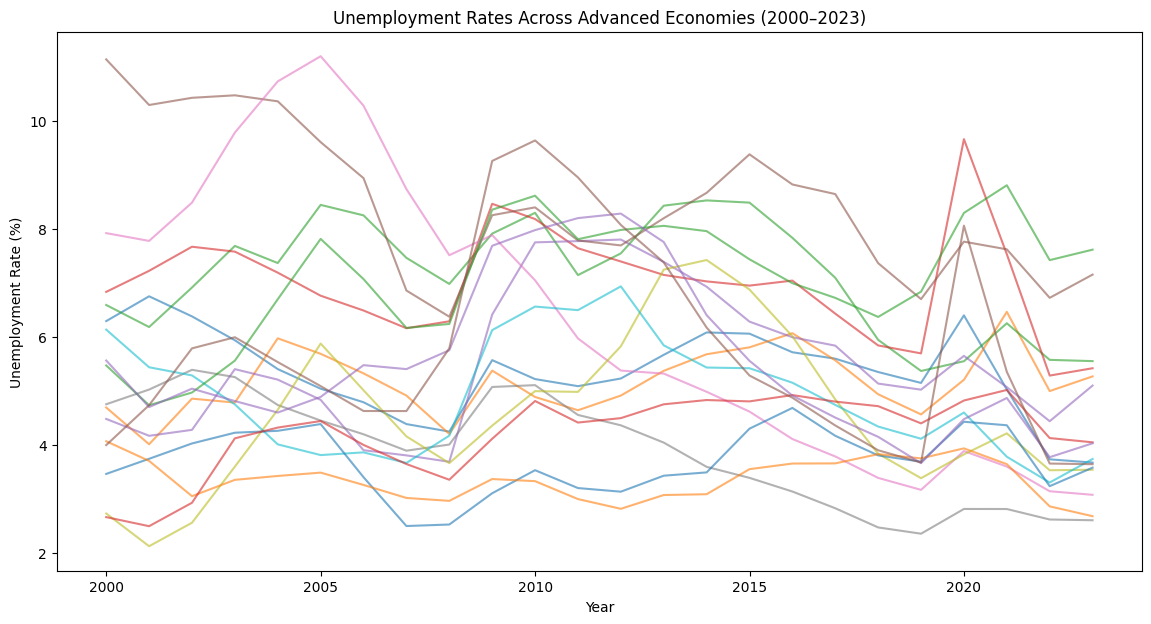

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for country in panel["Country"].unique():
    subset = panel[panel["Country"] == country]
    
    plt.plot(
        subset["Year"],
        subset["Unemployment"],
        alpha=0.6
    )

plt.title("Unemployment Rates Across Advanced Economies (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.show()

### Unemployment per COORD Category

Several countries experienced sharp increases in unemployment during the crises such as Global Financial Crisis and COVID-19 period. However, the magnitude and persistence of unemployment increases differed substantially across countries, suggesting potential institutional differences in labour market resilience.

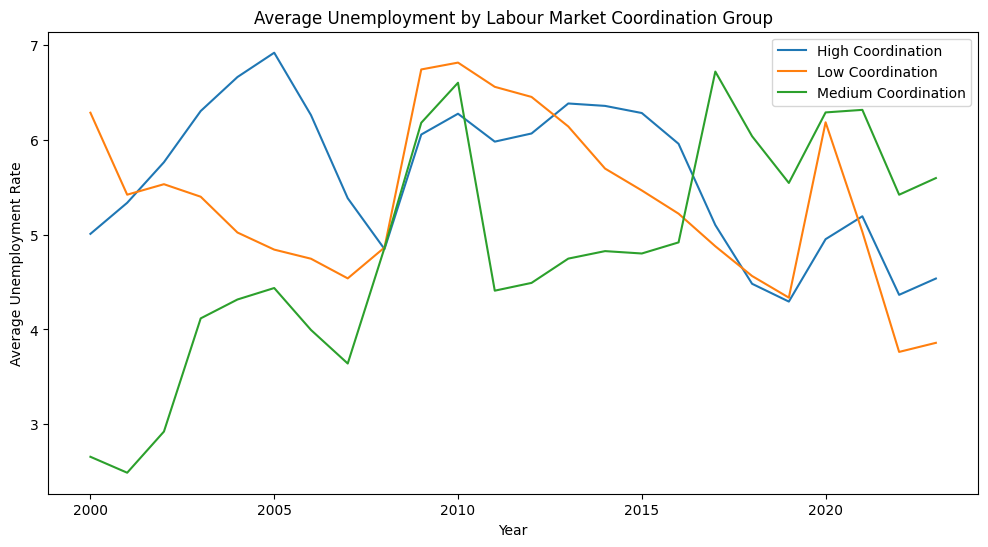

In [12]:
def coord_group(x):
    if x <= 2:
        return "Low Coordination"
    elif x <= 3:
        return "Medium Coordination"
    else:
        return "High Coordination"

panel["CoordGroup"] = panel["COORD"].apply(coord_group)

grouped = (
    panel.groupby(["Year", "CoordGroup"])["Unemployment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for group in grouped["CoordGroup"].unique():
    subset = grouped[grouped["CoordGroup"] == group]
    
    plt.plot(
        subset["Year"],
        subset["Unemployment"],
        label=group
    )

plt.legend()
plt.title("Average Unemployment by Labour Market Coordination Group")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")

plt.show()

The relationship between labour market coordination and unemployment resilience appears more mixed than initially expected.

Highly coordinated economies do not consistently display lower unemployment rates across the full sample period. In several years, particularly during the mid-2000s and post-2010 period, highly coordinated countries experienced unemployment rates comparable to or higher than less coordinated systems. However, differences in the timing and volatility of unemployment responses are still observable across coordination groups. Low coordination economies appear to experience sharper declines in unemployment during expansionary periods, but also exhibit notable fluctuations around major economic shocks such as the Global Financial Crisis and COVID-19 period. Medium coordination economies display the greatest volatility in several crisis and recovery periods, suggesting that institutional coordination alone may not fully explain labour market resilience.

Overall, the graph suggests that labour market coordination may interact with broader macroeconomic conditions, fiscal policy responses, industrial structure, and country-specific institutions rather than producing a simple linear relationship with unemployment outcomes. This motivates the need for multivariate panel regression analysis controlling for additional macroeconomic factors.

### Crisis Analysis

2008–2009 --> 2008 Financial Crisis
2020–2021 --> COVID-19

In [14]:
crisis_years = panel[
    panel["Year"].isin([2008, 2009, 2020, 2021])
]

crisis_years.groupby("CoordGroup")["Delta_Unemployment"].mean()

CoordGroup
High Coordination      0.438625
Low Coordination       0.724042
Medium Coordination    0.425500
Name: Delta_Unemployment, dtype: float64

During major crisis periods, highly coordinated economies tended to experience smaller average increases in unemployment relative to less coordinated systems.

In [15]:
panel[
    [
        "Unemployment",
        "COORD",
        "GDPGrowth",
        "Inflation",
        "ExportDependence",
        "GovSpend"
    ]
].corr()

,Unemployment,COORD,GDPGrowth,Inflation,ExportDependence,GovSpend
Unemployment,1.000000,0.064821,-0.107534,-0.150776,0.043593,0.361347
COORD,0.064821,1.000000,-0.203591,-0.142483,0.606212,0.488112
GDPGrowth,-0.107534,-0.203591,1.000000,0.208659,-0.020186,-0.248467
Inflation,-0.150776,-0.142483,0.208659,1.000000,0.070412,0.081546
ExportDependence,0.043593,0.606212,-0.020186,0.070412,1.000000,0.289822
GovSpend,0.361347,0.488112,-0.248467,0.081546,0.289822,1.000000


Preliminary correlations suggest that labour market coordination is associated with unemployment outcomes, although several macroeconomic variables are also strongly related to labour market performance.

This motivates the use of multivariate panel regression analysis.